In [1]:
from Configurations.imports import *

In [2]:
# creation of data set with anomalies
from sklearn.datasets import make_blobs
X,_ = make_blobs(n_samples=1000,centers=1, cluster_std=1,random_state=42)
X

array([[-1.47891417,  9.25307529],
       [-2.47719347,  8.26086826],
       [-2.40954626,  8.51081047],
       ...,
       [-0.84793841,  8.55718987],
       [-1.91444328,  9.86770169],
       [-2.29818016,  8.91757302]], shape=(1000, 2))

#### Isolation Forest

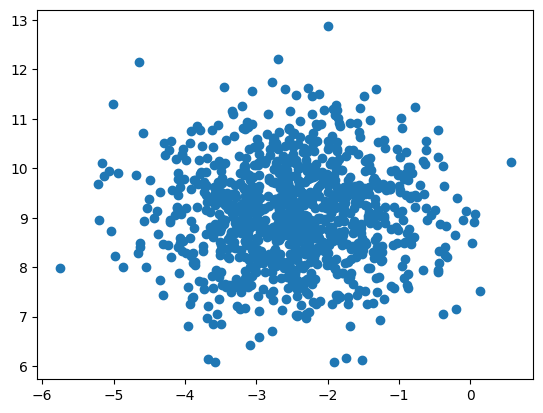

In [3]:
plt.scatter(X[:,0], X[:,1])

In [4]:
# creation of the outliers
outliers = np.random.uniform(low=-10,high=10,size=(20,2))
X = np.vstack([X, outliers])
X

array([[-1.47891417,  9.25307529],
       [-2.47719347,  8.26086826],
       [-2.40954626,  8.51081047],
       ...,
       [-7.22031733,  6.31634393],
       [ 9.70544216,  0.49048648],
       [-0.93863698,  2.10359005]], shape=(1020, 2))

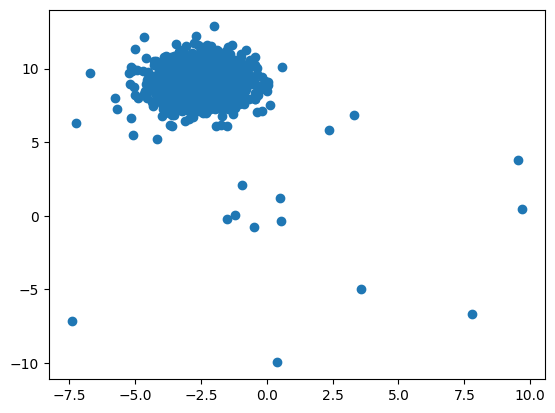

In [5]:
plt.scatter(X[:,0], X[:,1])

In [6]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(contamination=0.1)
model.fit(X)
preds = model.fit_predict(X)

In [7]:
# getting the outliers index
indices = np.where(preds < 0)
indices

(array([  17,   29,   46,   84,   86,  103,  105,  123,  139,  140,  142,
         156,  168,  177,  178,  185,  228,  234,  242,  249,  257,  293,
         301,  310,  311,  314,  336,  341,  376,  388,  390,  394,  410,
         418,  427,  432,  436,  450,  461,  462,  502,  510,  513,  524,
         531,  560,  573,  587,  594,  607,  618,  619,  620,  626,  694,
         695,  700,  711,  712,  722,  732,  751,  774,  776,  780,  783,
         794,  818,  830,  838,  848,  852,  860,  867,  882,  903,  906,
         909,  940,  947,  953,  962, 1000, 1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016,
        1017, 1018, 1019]),)

In [8]:



df = pd.DataFrame(X)

# example: indices of outliers
outlier_indices = np.array(indices).flatten()
outlier_indices.shape

normal_data = df.drop(index = outlier_indices)
normal_data


,0,1
0,-1.478914,9.253075
1,-2.477193,8.260868
2,-2.409546,8.510810
3,-3.369611,8.629731
4,-2.182270,8.795186
...,...,...
995,-1.636877,9.197628
996,-2.640455,9.091138
997,-0.847938,8.557190
998,-1.914443,9.867702


In [9]:
outliers = df.iloc[outlier_indices]

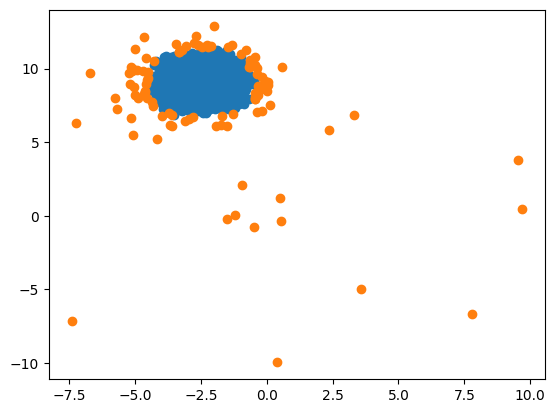

In [10]:
plt.scatter(normal_data.iloc[:,0], normal_data.iloc[:,1])
plt.scatter(outliers.iloc[:,0], outliers.iloc[:,1])

#### DBSACN Anomaly Detection

In [23]:
from sklearn.datasets import make_circles
X,_ = make_circles(n_samples=1000, factor=0.02, noise=0.1)
X

array([[ 0.92250953,  0.03879579],
       [-0.19675132,  0.10709272],
       [ 0.65820966,  0.73846074],
       ...,
       [-0.20820433, -0.01439954],
       [ 0.08196259, -0.07110713],
       [-0.83323564, -0.19801994]], shape=(1000, 2))

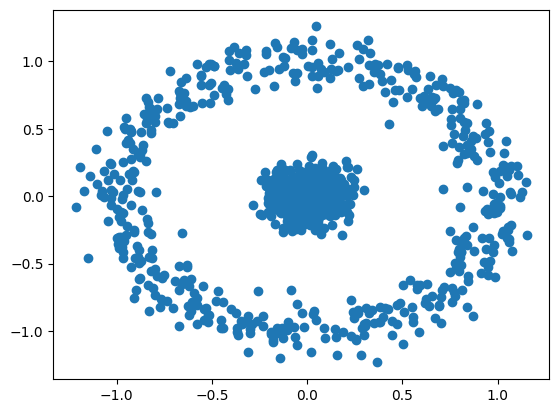

In [24]:
plt.scatter(X[:,0], X[:,1])

In [38]:
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.2, min_samples=10)
preds = model.fit_predict(X)

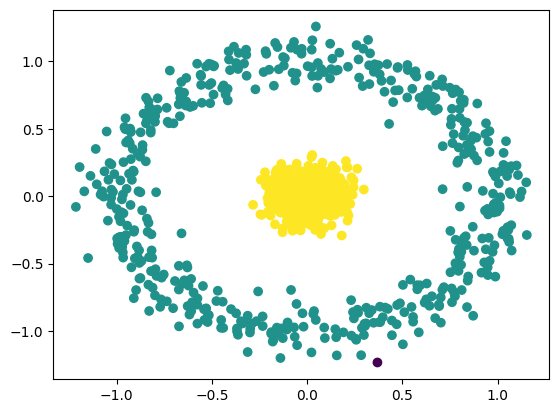

In [39]:
plt.scatter(X[:,0], X[:,1], c=preds)

#### Local Outlier Factor
